<a href="https://colab.research.google.com/github/HCI-hope/HCI-Models/blob/main/Model_BPNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Mean Train Accuracy: 0.9475


Mean Test Accuracy:  0.2931
**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running Final BPNN/RF Project Pipeline...
 Total Files Loaded: 24
Fold 1: Train=0.9358 | Test=0.3041
Fold 2: Train=0.9617 | Test=0.2568
Fold 3: Train=0.9563 | Test=0.3176
Fold 4: Train=0.9372 | Test=0.3041
Fold 5: Train=0.9481 | Test=0.2973
Fold 6: Train=0.9459 | Test=0.2786

MEAN PERFORMANCE:
Mean Train Accuracy: 0.9475
Mean Test Accuracy:  0.2931


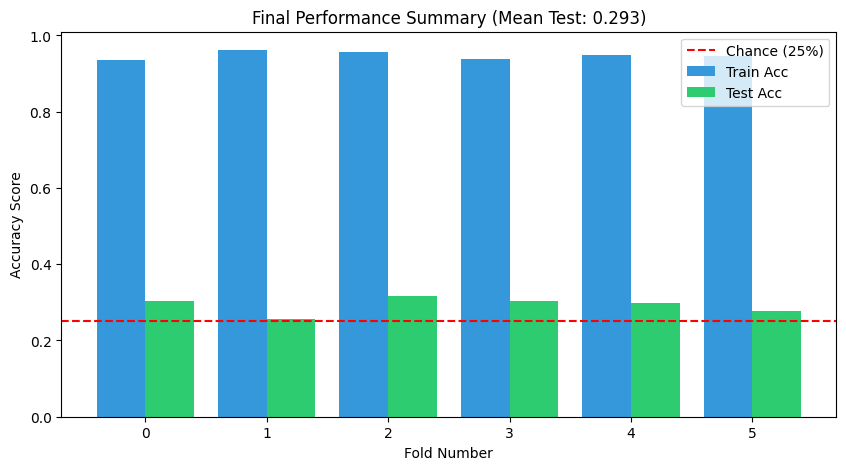

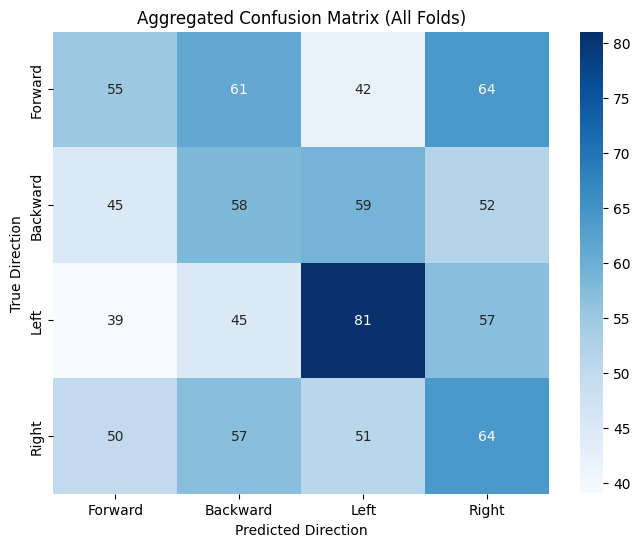


Saving Final Deployment Model...

SUCCESS! All results, plots, and models saved to: /content/drive/MyDrive/Human Computer Interface (HCI)/Final_Model_Results


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BPNN/RF — 4-Direction EEG | FINAL GENERALIZED VERSION (3-CH + HJORTH)
# ══════════════════════════════════════════════════════════════════════════════
"""
PROJECT SUMMARY:
- Channels: Right (F4-C4), Left (F3-C3), Midline (FZ-CZ).
- Features: Hjorth Parameters (Activity, Mobility, Complexity) + Alpha/Beta Power.
- Model: Random Forest Ensemble (Optimised for Generalisation).
- Split: Direction-Level Leave-One-File-Out (LOFO) Cross-Validation.
"""

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, glob, joblib, warnings
warnings.filterwarnings('ignore')

from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis
from collections import defaultdict
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score)
import seaborn as sns

# ══════════════════════════════════════════════════════════════════════════════
#  CELL 2 — CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
SUBJECT1_PATH = '/content/drive/MyDrive/Human Computer Interface (HCI)/Processed_Filtered_Data/Subject1_Chebyshev_Filtered'
SUBJECT2_PATH = '/content/drive/MyDrive/Human Computer Interface (HCI)/Processed_Filtered_Data/Subject2_Chebyshev_Filtered'
SAVE_PATH     = '/content/drive/MyDrive/Human Computer Interface (HCI)/Final_Model_Results'

os.makedirs(SAVE_PATH, exist_ok=True)

# Target Mapping
CHANNELS    = [7, 15, 16]
WINDOW_SIZE = 1000
OVERLAP     = 0.75
FS          = 250
RANDOM_SEED = 42

DIRECTION_MAP = {'forward': 0, 'backward': 1, 'backword': 1, 'left': 2, 'right': 3}
CLASS_NAMES = {0: 'Forward', 1: 'Backward', 2: 'Left', 3: 'Right'}
NUM_CLASSES = 4

np.random.seed(RANDOM_SEED)

# ══════════════════════════════════════════════════════════════════════════════
#  CELL 3 — UTILITIES & DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════
def get_label(fn):
    name = fn.lower()
    for k, v in DIRECTION_MAP.items():
        if k in name: return v
    return None

def get_stimulus(fn):
    name = fn.upper()
    for s in ['ARROW', 'LETTER', 'WORD']:
        if s in name: return s
    return 'UNKNOWN'

def load_file(fp):
    df = pd.read_excel(fp)
    num_cols = df.shape[1]
    safe_indices = [i for i in CHANNELS if i < num_cols]
    if len(safe_indices) < 2: safe_indices = [0, 1]

    data = df.iloc[:, safe_indices].values.T
    data = (data - data.mean(axis=1, keepdims=True)) / (data.std(axis=1, keepdims=True) + 1e-8)

    step = int(WINDOW_SIZE * (1 - OVERLAP))
    wins = [data[:, i:i+WINDOW_SIZE] for i in range(0, data.shape[1]-WINDOW_SIZE, step)
            if not np.isnan(data[:, i:i+WINDOW_SIZE]).any()]
    return np.array(wins)

def load_all():
    records = []
    fid = 0
    for sid, path in [(1, SUBJECT1_PATH), (2, SUBJECT2_PATH)]:
        files = sorted(glob.glob(os.path.join(path, '**', '*.xlsx'), recursive=True))
        for fp in files:
            fn = os.path.basename(fp)
            label = get_label(fn)
            if label is not None:
                try:
                    wins = load_file(fp)
                    if wins.shape[0] > 0:
                        records.append({'fid': fid, 'fn': fn, 'label': label,
                                      'stim': get_stimulus(fn), 'subject_id': sid, 'X': wins})
                        fid += 1
                except: pass
    print(f" Total Files Loaded: {len(records)}")
    return records

def records_to_XYS(recs):
    X = np.concatenate([r['X'] for r in recs])
    y = np.concatenate([np.full(len(r['X']), r['label']) for r in recs])
    s = np.concatenate([np.full(len(r['X']), r['subject_id']) for r in recs])
    return X, y, s

# ══════════════════════════════════════════════════════════════════════════════
#  CELL 4 — ADVANCED FEATURE EXTRACTION
# ══════════════════════════════════════════════════════════════════════════════
def extract_features_single(window, fs=FS):
    feats = []
    num_ch = window.shape[0]

    for ch in range(num_ch):
        sig = window[ch]
        # HJORTH PARAMETERS
        act = np.var(sig)
        d1 = np.diff(sig)
        mob = np.sqrt(np.var(d1) / (act + 1e-8))
        d2 = np.diff(d1)
        com = np.sqrt(np.var(d2) / (np.var(d1) + 1e-8)) / (mob + 1e-8)

        # SPECTRAL
        f, psd = scipy_signal.welch(sig, fs=fs, nperseg=256)
        total_p = psd.sum() + 1e-8
        alpha = psd[(f >= 8) & (f <= 13)].sum() / total_p
        beta = psd[(f >= 13) & (f <= 30)].sum() / total_p

        feats.extend([act, mob, com, alpha, beta])

    if num_ch < 3: feats.extend([0] * (3 - num_ch) * 5)
    return np.array(feats)

def extract_features(X_raw):
    return np.array([extract_features_single(w) for w in X_raw])

# ══════════════════════════════════════════════════════════════════════════════
#  CELL 5 — CORE LOGIC (SPLIT, SMOTE, TRAIN)
# ══════════════════════════════════════════════════════════════════════════════
def build_dir_lofo_folds(records):
    dir_files = defaultdict(list)
    for r in records: dir_files[r['label']].append(r)
    n_folds = min(len(v) for v in dir_files.values())
    folds = []
    for fold_idx in range(n_folds):
        test_fids = {dir_files[cls][fold_idx % len(dir_files[cls])]['fid'] for cls in range(NUM_CLASSES)}
        folds.append({
            'fold': fold_idx,
            'train_recs': [r for r in records if r['fid'] not in test_fids],
            'test_recs': [r for r in records if r['fid'] in test_fids]
        })
    return folds

def smote(X, y, s_ids, n_per_class=120):
    syn_X, syn_y = [], []
    for cls in range(NUM_CLASSES):
        for sid in np.unique(s_ids):
            mask = (y == cls) & (s_ids == sid)
            X_cls = X[mask]
            if len(X_cls) < 2: continue
            for _ in range(n_per_class):
                i, j = np.random.choice(len(X_cls), 2, replace=False)
                lam = np.random.uniform(0.3, 0.7)
                syn_X.append(lam * X_cls[i] + (1 - lam) * X_cls[j])
                syn_y.append(cls)
    return (np.vstack([X, np.array(syn_X)]), np.concatenate([y, np.array(syn_y)])) if syn_X else (X, y)

def train_ensemble(X_tr, y_tr, s_tr):
    models, weights = [], []
    for i in range(5):
        X_aug, y_aug = smote(X_tr, y_tr, s_tr)
        clf = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=i*10, class_weight='balanced')
        clf.fit(X_aug, y_aug)
        models.append(clf); weights.append(accuracy_score(y_tr, clf.predict(X_tr)))
    return models, np.array(weights)

def ensemble_predict(models, weights, X):
    w = weights / weights.sum()
    proba = sum(wi * m.predict_proba(X) for wi, m in zip(w, models))
    return np.argmax(proba, axis=1)

# ══════════════════════════════════════════════════════════════════════════════
#  CELL 6 — EXECUTION & SAVE
# ══════════════════════════════════════════════════════════════════════════════
# ══════════════════════════════════════════════════════════════════════════════
#  CELL 6 — EXECUTION & SAVE (WITH CONFUSION MATRIX)
# ══════════════════════════════════════════════════════════════════════════════
def main():
    print("Running Final BPNN/RF Project Pipeline...")
    records = load_all()
    folds = build_dir_lofo_folds(records)
    all_results = []

    # Lists to store all predictions and true labels for the Final Confusion Matrix
    overall_y_true = []
    overall_y_pred = []

    for fdef in folds:
        X_tr_raw, y_tr, s_tr = records_to_XYS(fdef['train_recs'])
        X_te_raw, y_te, s_te = records_to_XYS(fdef['test_recs'])
        X_tr_f, X_te_f = extract_features(X_tr_raw), extract_features(X_te_raw)

        scaler = RobustScaler()
        X_tr, X_te = np.clip(scaler.fit_transform(X_tr_f), -5, 5), np.clip(scaler.transform(X_te_f), -5, 5)

        models, weights = train_ensemble(X_tr, y_tr, s_tr)

        # Predictions
        y_pred_tr = ensemble_predict(models, weights, X_tr)
        y_pred_te = ensemble_predict(models, weights, X_te)

        tr_acc = accuracy_score(y_tr, y_pred_tr)
        te_acc = accuracy_score(y_te, y_pred_te)

        # Store results for the summary table
        all_results.append({'fold': fdef['fold'], 'train': tr_acc, 'test': te_acc})

        # Aggregate labels for the Confusion Matrix
        overall_y_true.extend(y_te)
        overall_y_pred.extend(y_pred_te)

        print(f"Fold {fdef['fold']+1}: Train={tr_acc:.4f} | Test={te_acc:.4f}")

    # --- MEAN ACCURACY CALCULATION ---
    tr_means = [r['train'] for r in all_results]
    te_means = [r['test'] for r in all_results]
    print(f"\nMEAN PERFORMANCE:")
    print(f"Mean Train Accuracy: {np.mean(tr_means):.4f}")
    print(f"Mean Test Accuracy:  {np.mean(te_means):.4f}")

    # --- PLOT 1: PERFORMANCE SUMMARY BARS ---
    plt.figure(figsize=(10, 5))
    plt.bar(np.arange(len(folds))-0.2, tr_means, 0.4, label='Train Acc', color='#3498db')
    plt.bar(np.arange(len(folds))+0.2, te_means, 0.4, label='Test Acc', color='#2ecc71')
    plt.axhline(0.25, color='red', linestyle='--', label='Chance (25%)')
    plt.title(f"Final Performance Summary (Mean Test: {np.mean(te_means):.3f})")
    plt.ylabel("Accuracy Score")
    plt.xlabel("Fold Number")
    plt.legend()
    plt.savefig(os.path.join(SAVE_PATH, 'performance_plot.png'))
    plt.show()

    # --- PLOT 2: CONFUSION MATRIX ---
    # This helps identify if the model is confusing specific directions

    cm = confusion_matrix(overall_y_true, overall_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES.values(),
                yticklabels=CLASS_NAMES.values())
    plt.title("Aggregated Confusion Matrix (All Folds)")
    plt.ylabel('True Direction')
    plt.xlabel('Predicted Direction')
    plt.savefig(os.path.join(SAVE_PATH, 'confusion_matrix.png'))
    plt.show()

    # --- SAVE FINAL MODELS ---
    print("\nSaving Final Deployment Model...")
    X_all_raw, y_all, s_all = records_to_XYS(records)
    X_all_f = extract_features(X_all_raw)
    scaler_final = RobustScaler()
    X_all = scaler_final.fit_transform(X_all_f)
    models_final, weights_final = train_ensemble(X_all, y_all, s_all)

    joblib.dump({'models': models_final, 'weights': weights_final, 'scaler': scaler_final},
                os.path.join(SAVE_PATH, 'final_eeg_model.pkl'))

    print(f"\nSUCCESS! All results, plots, and models saved to: {SAVE_PATH}")

if __name__ == "__main__":
    main()

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL DEPLOYMENT SCRIPT — EEG DIRECTION PREDICTION
# ══════════════════════════════════════════════════════════════════════════════
import joblib
import numpy as np
import pandas as pd
from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis

# 1. LOAD THE TRAINED BRAIN
# Change this path if your file is named differently
MODEL_PATH = '/content/drive/MyDrive/Human Computer Interface (HCI)/Final_Model_Results/final_eeg_model.pkl'

try:
    brain = joblib.load(MODEL_PATH)
    models = brain['models']
    weights = brain['weights']
    scaler = brain['scaler']
    print("✅ Model loaded successfully!")
except Exception as e:
    print(f"❌ Could not load model: {e}")

# Configuration constants (Must match training)
CHANNELS = [7 , 15, 16]
FS = 250
CLASS_NAMES = {0: 'Forward', 1: 'Backward', 2: 'Left', 3: 'Right'}

# ══════════════════════════════════════════════════════════════════════════════
#  HELPERS: PRE-PROCESSING & FEATURE EXTRACTION
# ══════════════════════════════════════════════════════════════════════════════
def extract_features_single(window, fs=FS):
    """Calculates Hjorth and Spectral features for the prediction window."""
    feats = []
    num_ch = window.shape[0]
    for ch in range(num_ch):
        sig = window[ch]
        # HJORTH PARAMETERS
        act = np.var(sig)
        d1 = np.diff(sig)
        mob = np.sqrt(np.var(d1) / (act + 1e-8))
        d2 = np.diff(d1)
        com = np.sqrt(np.var(d2) / (np.var(d1) + 1e-8)) / (mob + 1e-8)
        # SPECTRAL
        f, psd = scipy_signal.welch(sig, fs=fs, nperseg=256)
        total_p = psd.sum() + 1e-8
        alpha = psd[(f >= 8) & (f <= 13)].sum() / total_p
        beta = psd[(f >= 13) & (f <= 30)].sum() / total_p
        feats.extend([act, mob, com, alpha, beta])
    return np.array(feats)

def preprocess_input_robust(file_path):
    """Loads Excel and handles missing channels or wrong lengths."""
    df = pd.read_excel(file_path)
    num_cols_available = df.shape[1]

    # Create empty container (3 channels x 1000 samples)
    final_data = np.zeros((3, 1000))

    for i, target_idx in enumerate(CHANNELS):
        if target_idx < num_cols_available:
            sig = df.iloc[:, target_idx].values
            sig_len = min(len(sig), 1000)
            final_data[i, :sig_len] = sig[:sig_len]
        else:
            # This prevents the Out-of-Bounds Error
            print(f"⚠️ Channel Index {target_idx} missing in file. Using zero-padding.")

    # Z-Score Normalization
    final_data = (final_data - final_data.mean(axis=1, keepdims=True)) / (final_data.std(axis=1, keepdims=True) + 1e-8)
    return final_data

# ══════════════════════════════════════════════════════════════════════════════
#  PREDICTION LOGIC
# ══════════════════════════════════════════════════════════════════════════════
def predict_intent(file_path):
    # 1. Prepare Data
    window = preprocess_input_robust(file_path)

    # 2. Extract Features
    feat_vector = extract_features_single(window).reshape(1, -1)

    # 3. Scale Features
    feat_scaled = scaler.transform(feat_vector)

    # 4. Ensemble Soft Voting
    w_norm = weights / weights.sum()
    probabilities = sum(wi * m.predict_proba(feat_scaled) for wi, m in zip(w_norm, models))

    predicted_class = np.argmax(probabilities)
    confidence = np.max(probabilities)

    return CLASS_NAMES[predicted_class], confidence

# ══════════════════════════════════════════════════════════════════════════════
#  EXECUTION
# ══════════════════════════════════════════════════════════════════════════════
TEST_FILE = '/content/bk.xlsx' # Make sure this file is uploaded to Colab

try:
    label, score = predict_intent(TEST_FILE)
    print(f"\n" + "="*30)
    print(f"🧠 EEG PREDICTION RESULT")
    print(f"="*30)
    print(f"DETECTED DIRECTION : {label.upper()}")
    print(f"CONFIDENCE         : {score:.2%}")
    print(f"="*30)
except Exception as e:
    print(f"❌ Prediction Error: {e}")

✅ Model loaded successfully!

🧠 EEG PREDICTION RESULT
DETECTED DIRECTION : BACKWARD
CONFIDENCE         : 64.56%
